# Picrosirius Red Collagen Analysis
- *Bel Taylor-Hearn, 2025*
- Aim to quantify amount and alignment of collagen around ducts, and determine if it is aligned parallel or perpendicularly to theduct


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import pandas as pd

from skimage import util
from skimage.io import imread
from skimage.color import rgb2hsv, rgb2gray
from skimage.filters import gaussian, threshold_triangle, threshold_otsu, threshold_li, threshold_isodata, threshold_minimum, try_all_threshold, threshold_mean
from skimage.exposure import adjust_gamma
from skimage.feature import structure_tensor
from skimage.segmentation import expand_labels, flood, clear_border
from skimage.measure import label,  regionprops_table, find_contours
from skimage.morphology import remove_small_holes, closing, disk, opening, remove_small_objects, rectangle, erosion

from scipy.ndimage import distance_transform_edt
from scipy.interpolate import splprep, splev
from skimage.draw import polygon
import tifffile

import contextlib
import joblib
from joblib import Parallel, delayed
from tqdm import tqdm

In [2]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.

    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [3]:
def segment_duct(image_path, ring_width_um=10):
    """
    Segment the largest duct-like structure from a grayscale or RGB image and extract a surrounding ring region.
    
    Also returns areas and an edge-touching flag.

    Parameters:
    ----------
    image_path : str
        Path to input image (2D grayscale or 3D RGB) representing tissue or duct-containing microscopy data.
    ring_width_um : float, optional
        Width of the extracted ring in microns (default is 10 µm).

    Returns:
    -------
    original_image : np.ndarray
        The loaded image.
    ring_mask : np.ndarray (bool)
        Binary mask representing a ring-shaped region around the segmented duct.
    collagen_of_interest : np.ndarray
        Original image masked to the ring region.
    smoothed_duct : np.ndarray (bool)
        Binary mask of the duct after smoothing its boundary.
    ring_area_um2 : float
        Area of the ring mask in square microns.
    duct_area_um2 : float
        Area of the duct (smoothed mask) in square microns.
    touches_edge : bool
        True if either the duct or the ring mask touches the edge of the image.
    """
    original_image = imread(image_path)
    clipped = rgb2gray(original_image.clip(min=0, max=np.quantile(original_image, 0.95)))
    smoothed = gaussian(clipped, sigma=12)
    thresh = threshold_triangle(smoothed)
    segmented = smoothed > thresh
    inverted = util.invert(segmented)

    h, w = inverted.shape
    mask_tl = flood(inverted, seed_point=(0, 0))
    mask_tr = flood(inverted, seed_point=(0, w - 1))
    mask_bl = flood(inverted, seed_point=(h - 1, 0))
    mask_br = flood(inverted, seed_point=(h - 1, w - 1))
    background_mask = mask_tl | mask_tr | mask_bl | mask_br

    cleaned = inverted & ~background_mask
    cleaned = remove_small_holes(cleaned, area_threshold=500)
    cleaned = closing(cleaned, disk(5))
    labelled_ducts = label(cleaned)
    labelled_ducts = clear_border(labelled_ducts)

    table = regionprops_table(labelled_ducts, properties=('label', 'area'))
    condition = (table['area'] >= (table['area']).max())
    
    input_labels = table['label']
    output_labels = input_labels * condition
    largest_duct = util.map_array(labelled_ducts, input_labels, output_labels)
    largest_duct = largest_duct > 0

    print("ORIG identified area is", (table['area']).max(), "whole area is", h*w*0.05, "ratio is", (table['area']).max()/(h*w*0.05))

    if (table['area']).max() < h*w*0.05: #if only a tiny item if identified, something has probably gone wrong
        print("HERE")
        clipped = rgb2gray(original_image.clip(min=np.quantile(original_image, 0.3), max=np.quantile(original_image, 1)))

        smoothed = gaussian(clipped, sigma=6)
        thresh = threshold_triangle(smoothed)
        segmented = smoothed > thresh
        inverted = util.invert(segmented)


        h, w = inverted.shape
        mask_tl = flood(inverted, seed_point=(0, 0))
        mask_tr = flood(inverted, seed_point=(0, w - 1))
        mask_bl = flood(inverted, seed_point=(h - 1, 0))
        mask_br = flood(inverted, seed_point=(h - 1, w - 1))
        background_mask = mask_tl | mask_tr | mask_bl | mask_br

        cleaned = inverted & ~background_mask
        cleaned = remove_small_holes(cleaned, area_threshold=500)
        cleaned = closing(cleaned, disk(5))


        fig, ax = plt.subplots(ncols = 4)
        ax[0].imshow(smoothed, cmap="gray")

        ax[1].imshow(smoothed, cmap="gray")
        ax[2].imshow(segmented, cmap="gray")
        ax[3].imshow(cleaned, cmap="gray")

        labelled_ducts = label(cleaned)
        labelled_ducts = clear_border(labelled_ducts)

        table = regionprops_table(labelled_ducts, properties=('label', 'area'))
        condition = (table['area'] >= (table['area']).max())
        
        input_labels = table['label']
        output_labels = input_labels * condition
        largest_duct = util.map_array(labelled_ducts, input_labels, output_labels)
        largest_duct = largest_duct > 0
        print("RERUN identified area is", (table['area']).max(), "whole area is", h*w*0.05, "ratio is", (table['area']).max()/(h*w*0.05))


    contour = find_contours(largest_duct.astype(float), level=0.5)[0]
    x, y = contour[:, 1], contour[:, 0]
    tck, u = splprep([x, y], s=5000)
    new_points = splev(np.linspace(0, 1, len(x)), tck)

    smoothed_duct = np.zeros_like(largest_duct, dtype=bool)
    rr, cc = polygon(new_points[1], new_points[0], largest_duct.shape)
    smoothed_duct[rr, cc] = 1
    smoothed_labelled_duct = expand_labels(label(smoothed_duct),13)

    pixel_size_um = pixel_size(image_path)  # Your existing function
    number_of_pixels = ring_width_um / pixel_size_um

    outer = expand_labels(smoothed_labelled_duct, distance=int(number_of_pixels)+1)
    inner = expand_labels(smoothed_labelled_duct, distance=1)
    ring_mask = (outer > 0) & (inner == 0)

    collagen_of_interest = original_image.copy()
    collagen_of_interest[~ring_mask] = 0
    total_collagen = np.sum(collagen_of_interest)

    ring_area_um2 = np.sum(ring_mask) * (pixel_size_um ** 2)
    duct_area_um2 = np.sum(smoothed_duct) * (pixel_size_um ** 2)

    # Check if any pixel along the edges is True
    touches_edge = np.any(ring_mask[0, :]) or np.any(ring_mask[-1, :]) or np.any(ring_mask[:, 0]) or np.any(ring_mask[:, -1])
    if touches_edge == True:
        flag = "identified object touches edge!"
    else:
        flag = "none"

    return original_image, ring_mask, collagen_of_interest, smoothed_duct, ring_area_um2, duct_area_um2, flag, total_collagen


In [4]:
def red_green_ratio (original_image, ring_mask):
    """
    Calculate the red-to-green pixel ratio within a specified ring region of an RGB image.

    Parameters:
    ----------
    original_image : np.ndarray
        The original RGB image (3D array with shape HxWx3).
    ring_mask : np.ndarray (bool)
        Binary mask (2D) specifying the region of interest within which to calculate red and green pixels.

    Returns:
    -------
    ratio : float
        The ratio of red pixels to green pixels within the masked region.
    red_mask : np.ndarray (bool)
        Binary mask of red-hued pixels within the ring region.
    green_mask : np.ndarray (bool)
        Binary mask of green-hued pixels within the ring region.

    Notes:
    -----
    - The image is converted to HSV space to identify hue-based red and green regions.
    - Red is defined as hue < 0.05 or > 0.95 (wrapping around the hue scale).
    - Green is defined as hue between 0.25 and 0.45.
    - A small epsilon (1e-5) is added to the denominator to avoid division by zero.
    - Useful for quantifying colour shifts in labelled ducts or collagen rings.

    Example:
    --------
    ratio, red_mask, green_mask = red_green_ratio(image, mask)
    """
    hsv = rgb2hsv(original_image)
    hue = hsv[:, :, 0]
    red_mask = ((hue < 0.05) | (hue > 0.95)) & ring_mask
    green_mask = ((hue > 0.25) & (hue < 0.45)) & ring_mask
    num_red = np.sum(red_mask)
    num_green = np.sum(green_mask)
    ratio = num_red / (num_green + 1e-5)

    print(f"Red pixels: {num_red}, Green pixels: {num_green}, Red:Green ratio: {ratio:.2f}")
    return ratio, red_mask, green_mask, num_red, num_green


In [5]:
def quantify_alignment(original_image, ring_mask, smoothed_duct, fiber_mask=None):
    """
    Quantify collagen fiber alignment relative to radial vectors from a duct boundary, optionally restricted to a fiber mask.

    Parameters:
    ----------
    original_image : np.ndarray
        The original RGB image (HxWx3) from which fiber orientations are derived.
    ring_mask : np.ndarray (bool)
        Binary mask representing the ring region surrounding the duct.
    smoothed_duct : np.ndarray (bool)
        Binary mask of the duct after contour smoothing.
    fiber_mask : np.ndarray (bool), optional
        Optional binary mask to restrict analysis to selected fibers (e.g., thick fibers from red_mask). Default is None.

    Returns:
    -------
    sample_idx : np.ndarray
        Array of randomly selected indices from the analyzed region (used for overlay plotting).
    x_coords : np.ndarray
        X-coordinates of analyzed pixels.
    y_coords : np.ndarray
        Y-coordinates of analyzed pixels.
    alignment_map : np.ndarray
        2D array with alignment scores at analyzed locations.
    alignment_score : np.ndarray
        Per-pixel radial alignment scores (cos²θ) between fiber direction and radial vector.
    rx : np.ndarray
        X-components of unit radial vectors.
    ry : np.ndarray
        Y-components of unit radial vectors.
    """
    dist_out = distance_transform_edt(~smoothed_duct)
    dist_in = distance_transform_edt(smoothed_duct)
    signed_dist = dist_out - dist_in
    grad_y, grad_x = np.gradient(signed_dist)
    magnitude = np.sqrt(grad_x**2 + grad_y**2) + 1e-8
    norm_x = grad_x / magnitude
    norm_y = grad_y / magnitude

    combined_mask = ring_mask.copy()
    if fiber_mask is not None:
        combined_mask = ring_mask & fiber_mask

    y_coords, x_coords = np.nonzero(combined_mask)
    rx = norm_x[y_coords, x_coords]
    ry = norm_y[y_coords, x_coords]

    grayscale = rgb2gray(original_image)
    smooth = gaussian(grayscale, sigma=2)
    Axx, Axy, Ayy = structure_tensor(smooth, sigma=3)
    orientation = 0.5 * np.arctan2(2 * Axy, Axx - Ayy)
    fiber_angle = orientation[y_coords, x_coords]
    fx = np.cos(fiber_angle)
    fy = np.sin(fiber_angle)

    dot_product = fx * rx + fy * ry
    alignment_score = dot_product ** 2  # cos²(theta)

    print(f"Mean radial alignment score: {np.mean(alignment_score):.3f}")

    alignment_map = np.zeros_like(grayscale)
    alignment_map[y_coords, x_coords] = alignment_score

    if len(x_coords) >= 50:
        sample_idx = np.random.choice(len(x_coords), size=50, replace=False)
    else:
        sample_idx = np.arange(len(x_coords))

    return sample_idx, x_coords, y_coords, alignment_map, alignment_score, rx, ry


In [6]:
def plot_outputs(image_path, original_image, ring_mask, collagen_of_interest, smoothed_duct, red_mask, green_mask, x_coords, y_coords, rx, ry, sample_idx, alignment_map, save_type="png"):
    """
    Generate summary visualisations of duct segmentation, red/green channel distribution,
    and collagen fiber alignment relative to duct boundaries.

    Plot 1: shows overlay of original image with a semi-transparent duct overlay. The collagen
    of interest is also shown, alongside the red and green identified signal.

    Plot 2: confirms radial direction has been correctly identified and shows the alignment between
    collagen fibers and the identified radial direction.

    Parameters:
    ----------
    original_image : np.ndarray
        Original RGB image used for analysis.
    ring_mask : np.ndarray (bool)
        Binary mask defining the ring-shaped region surrounding the duct.
    collagen_of_interest : np.ndarray
        Version of the original image with pixels outside the ring masked out.
    smoothed_duct : np.ndarray (bool)
        Binary mask of the segmented duct with smoothed boundary.
    red_mask : np.ndarray (bool)
        Binary mask identifying red-hued pixels within the ring.
    green_mask : np.ndarray (bool)
        Binary mask identifying green-hued pixels within the ring.
    x_coords : np.ndarray
        X-coordinates of pixels within the ring region.
    y_coords : np.ndarray
        Y-coordinates of pixels within the ring region.
    rx : np.ndarray
        X-components of radial unit vectors at each ring pixel.
    ry : np.ndarray
        Y-components of radial unit vectors at each ring pixel.
    sample_idx : np.ndarray
        Randomly selected subset of indices used for quiver arrow overlay.
    alignment_map : np.ndarray
        Per-pixel heatmap of radial alignment scores (cos²θ) for collagen fibers.
    save_type: string
        Type of image to save, e.g. png, pdf

    Returns:
    -------
    None
        Displays summary figures using matplotlib.
    """
    filename = os.path.basename(image_path).replace("_", "").lower().replace(".tif", "")

    smoothed_duct = expand_labels(smoothed_duct, 10)
    duct_rgb = np.zeros((*smoothed_duct.shape, 4))  # RGBA
    duct_rgb[smoothed_duct] = [0.1176, 0.5647, 1.0, 0.5]  # yellow with alpha

    ring_rgb = np.zeros((*ring_mask.shape, 4))  # RGBA
    ring_rgb[ring_mask] = [0.1176, 0.5647, 1.0, 0.5]  # yellow with alpha

    fig, ax = plt.subplots(ncols = 6, figsize=(20,7))
    ax[0].imshow(original_image)
    ax[1].imshow(original_image)
    ax[1].imshow(duct_rgb)
    ax[2].imshow(original_image)
    ax[2].imshow(ring_rgb)
    ax[3].imshow(collagen_of_interest)
    ax[4].imshow(red_mask, cmap="Reds")
    ax[5].imshow(green_mask, cmap="Greens")
    titles = ["Original", "Duct", "ROI", "Collagen of Interest", "Reds", "Greens"]
    for i, a in enumerate(ax):
        a.axis("off")
        a.set_title(titles[i])
    plt.savefig("{}_segmentation.{}".format(filename, save_type), bbox_inches = "tight", transparent = True)
    arrow_scale = 10
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Subplot 1: Quiver overlay to check the correct "outward" direction has been aligned
    axs[0].imshow(rgb2gray(original_image), cmap='gray')
    # axs[0].quiver(x_coords[sample_idx], y_coords[sample_idx],
    #               fx[sample_idx] * arrow_scale, -fy[sample_idx] * arrow_scale,
    #               color='red', scale=100, width=0.004, pivot='middle', label='Fiber')
    axs[0].quiver(x_coords[sample_idx], y_coords[sample_idx],
                rx[sample_idx] * arrow_scale, -ry[sample_idx] * arrow_scale,
                color='limegreen', scale=100, width=0.004, pivot='middle', label='Radial')
    axs[0].imshow(duct_rgb, alpha=0.5)
    axs[0].legend()
    axs[0].set_title("Radial Directions")
    axs[0].axis('off')

    # Subplot 2: Alignment heatmap
    im = axs[1].imshow(alignment_map, cmap='inferno')
    axs[1].set_title("Radial Alignment Heatmap")
    axs[1].axis('off')
    fig.colorbar(im, ax=axs[1], label='cos²(angle)')

    plt.tight_layout()
    plt.savefig("{}_alignment.{}".format(filename, save_type), bbox_inches = "tight", transparent = True)

    plt.show()



In [7]:
def pixel_size(tif_path):
    """
    Extracts the pixel size (spacing) in microns from a TIFF image.

    This function reads TIFF metadata to determine the pixel spacing in the x, y, and z 
    dimensions, returning them as a list.

    Parameters:
    -----------
    tif_path : str
        Path to the TIFF file.

    Returns:
    --------
    original_spacing : list of float
        A list containing the pixel sizes in microns: [x_pixel_size_um, y_pixel_size_um, z_pixel_size_um].

    Notes:
    ------
    - The x and y resolutions are extracted from the TIFF XResolution and YResolution tags.
    - The z-spacing is inferred from the `IJMetadata` tag if available; otherwise, it falls back to 
      the `ImageDescription` tag.
    - Assumes the metadata is formatted in a way compatible with ImageJ or similar software.
    """
    with tifffile.TiffFile(tif_path) as tif:
        tif_tags = {}
        for tag in tif.pages[0].tags.values():
            name, value = tag.name, tag.value
            tif_tags[name] = value

        pixel_size_um = 1/((tif_tags["XResolution"])[0]/(tif_tags["XResolution"][1]))
       
    return pixel_size_um

In [8]:
def add_image_details(df, filename, flag):
    """
    Adds experimental details extracted from the filename to a dataframe.

    This function parses the filename to infer experimental details such as 
    well number, imaging day, mechanical stiffness condition, and treatment type.
    The extracted details are appended as new columns to the dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to which image metadata will be added.
    filename : str
        The filename of the image, used to extract experimental details.
    flag : str
        A flag indicating any segmentation issues detected during processing.

    Returns:
    --------
    df : pandas.DataFrame
        The updated dataframe with the following added columns:
        - 'filename': The original filename.
        - 'flag': Segmentation flag indicating potential issues.
        - 'condition': WT, Nic, Tom or Nictom (or unknown if no match found)
    """
    df["flag"] = flag
    if 'nictom' in filename.lower().replace("_", ""):
        df["condition"] =  'nictom'
    elif 'nic' in filename.lower().replace("_", ""):
        df["condition"] =  'nic'
    elif 'tom' in filename.lower().replace("_", ""):
        df["condition"] = "tom"
    elif 'wt' in filename.lower().replace("_", ""):
        df["condition"] = "wt"
    else:
        df["condition"] = "unknown!"
    return df

In [9]:
def segment_and_quantify(image_paths, i):
    try:
        original_image, ring_mask, collagen_of_interest, smoothed_duct, ring_area_um2, duct_area_um2, flag, total_collagen = segment_duct(image_paths[i])
        ratio, red_mask, green_mask, num_red, num_green = red_green_ratio (original_image, ring_mask)
        sample_idx, x_coords, y_coords, alignment_map, alignment_score, rx, ry = quantify_alignment(original_image, ring_mask, smoothed_duct)
        sample_idx_thick, x_coords_thick, y_coords_thick, alignment_map_thick, alignment_score_thick, rx_thick, ry_thick = quantify_alignment(original_image, ring_mask, smoothed_duct, fiber_mask=red_mask)

        plot_outputs(image_paths[i], original_image, ring_mask, collagen_of_interest, smoothed_duct, red_mask, green_mask, x_coords, y_coords, rx, ry, sample_idx, alignment_map)
        plt.close()
        outputs = pd.DataFrame([{
            "Image": os.path.basename(image_paths[i]).lower().replace(".tif", ""),
            "Total_Collagen": total_collagen,
            "Duct_Area_um2": duct_area_um2,
            "Ring_Area_um2": ring_area_um2,
            "Red_Pixels": num_red,
            "Green_Pixels": num_green,
            "Red_Green_Ratio": ratio,
            "Total_Alignment": np.round(np.mean(alignment_score),2),
            "Thick_Alignment": np.round(np.mean(alignment_score_thick),2)
        }])
        outputs = add_image_details(outputs, os.path.basename(image_paths[i]), flag)
    except:
            outputs = pd.DataFrame([{
            "Image": os.path.basename(image_paths[i]).lower().replace(".tif", ""),
            "Flag": "Segmentation Failed"
        }])
    return outputs



In [10]:
image_root = "C:/Users/itayl/The University of Manchester Dropbox/Isobel Taylor-Hearn/Picrosirius_Red_Stain_Quantification/NicTom_Dataset/WT"
image_paths = list(pathlib.Path(image_root).rglob("*.{}".format("tif")))
for i, path in enumerate(image_paths):
    if "1_4" in str(path):
        print(i, path)

4 C:\Users\itayl\The University of Manchester Dropbox\Isobel Taylor-Hearn\Picrosirius_Red_Stain_Quantification\NicTom_Dataset\WT\WT_354189\354189_WT_gland1_4.tif
24 C:\Users\itayl\The University of Manchester Dropbox\Isobel Taylor-Hearn\Picrosirius_Red_Stain_Quantification\NicTom_Dataset\WT\WT_371118\37118_WT_Gland1_4.tif


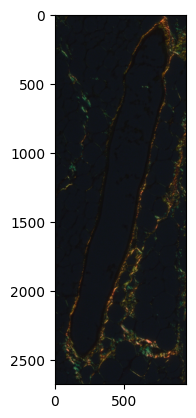

In [50]:
i = 4

plt.imshow(imread(image_paths[i]))
# original_image = rgb2gray(imread(image_paths[i]))
# plt.imshow(original_image, cmap="gray")

In [ ]:


gamma_correct = adjust_gamma(original_image, gamma = 10**-15, gain=10**10)



# try_all_threshold(gamma_correct) #mean, isodata, li, triangle
thresh = threshold_triangle(gamma_correct)
thresholded = gamma_correct > thresh

smooth = gaussian(thresholded, sigma = 4)
thresh2 = threshold_triangle(smooth)
thresholded2 = smooth> thresh2
# inverted = util.invert(thresholded2)


smooth2 = gaussian(thresholded2, sigma=4)
thresh3 = threshold_triangle(smooth2)
thresholded3 = smooth2> thresh2


fig, ax = plt.subplots(ncols = 2, figsize=(15,5))
ax[0].imshow(thresholded2, cmap="gray")
ax[1].imshow(thresholded3, cmap="gray")


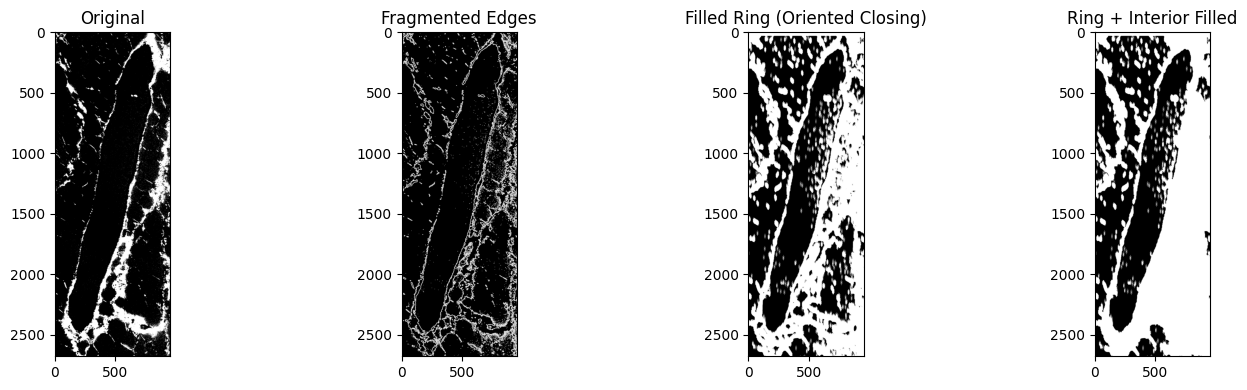

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.filters import gaussian, sobel
from skimage.feature import structure_tensor
from skimage.morphology import binary_closing
from scipy.ndimage import binary_fill_holes
import cv2

# --- Step 1: Load grayscale image and smooth ---

smooth = gaussian(thresholded, sigma=1)

# --- Step 2: Detect fragmented ring edges (white lines) ---
edges = sobel(smooth)
ring_edges = edges > 0.1  # adjust if needed

# --- Step 3: Compute structure tensor ---
Axx, Axy, Ayy = structure_tensor(smooth, sigma=1.5)
tmp = 0.5 * (Axx + Ayy)
delta = np.sqrt(0.25 * (Axx - Ayy)**2 + Axy**2)
lambda1 = tmp + delta
lambda2 = tmp - delta
orientation = 0.5 * np.arctan2(2 * Axy, Axx - Ayy)
coherence = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-6)

# --- Step 4: Guided morphological closing using oriented kernels ---
angles_deg = np.arange(0, 180, 45)
filled_ring = ring_edges.copy()

for angle in angles_deg:
    # Create and rotate a line kernel
    selem = cv2.getStructuringElement(cv2.MORPH_RECT, (75, 1))
    M = cv2.getRotationMatrix2D((7, 0), angle, 1)
    rotated = cv2.warpAffine(selem, M, (15, 15), flags=cv2.INTER_NEAREST)

    # OpenCV needs uint8
    ring_uint8 = (filled_ring * 255).astype(np.uint8)
    closed = cv2.morphologyEx(ring_uint8, cv2.MORPH_CLOSE, rotated)
    filled_ring = np.logical_or(filled_ring, closed > 0)

# --- Step 5: Fill the interior if desired ---
filled_area = binary_fill_holes(filled_ring)

# --- Step 6: Visualize ---
plt.figure(figsize=(15, 4))
plt.subplot(1, 4, 1)
plt.imshow(thresholded, cmap='gray')
plt.title("Original")

plt.subplot(1, 4, 2)
plt.imshow(ring_edges, cmap='gray')
plt.title("Fragmented Edges")

plt.subplot(1, 4, 3)
plt.imshow(filled_ring, cmap='gray')
plt.title("Filled Ring (Oriented Closing)")

plt.subplot(1, 4, 4)
plt.imshow(filled_area, cmap='gray')
plt.title("Ring + Interior Filled")

plt.tight_layout()
plt.show()


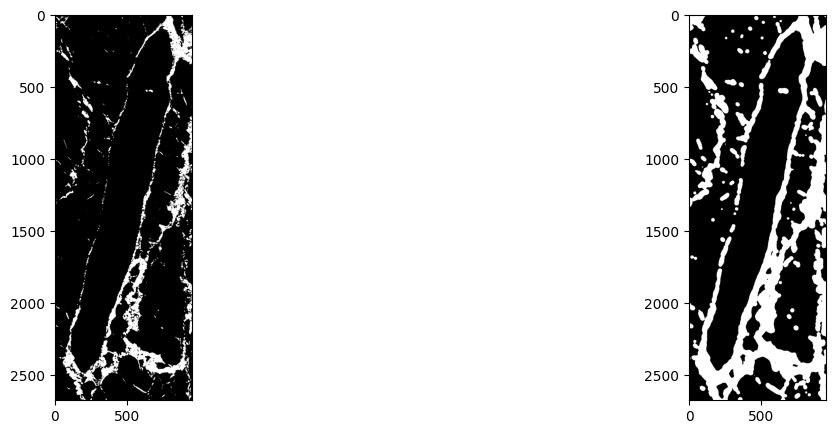

In [75]:

from skimage.measure import label, regionprops
from scipy.ndimage import binary_erosion, rotate, binary_opening, binary_dilation

i = 4
original_image = rgb2gray(imread(image_paths[i]))


gamma_correct = adjust_gamma(original_image, gamma = 10**-15, gain=10**10)
gamma_correct = gaussian(gamma_correct, sigma=1)


# try_all_threshold(gamma_correct) #mean, isodata, li, triangle
thresh = threshold_triangle(gamma_correct)
thresholded = gamma_correct > thresh

smooth = gaussian(thresholded, sigma = 6)
thresh2 = threshold_triangle(smooth)
thresholded2 = smooth> thresh2


fig, ax = plt.subplots(ncols = 2, figsize=(15,5))
ax[0].imshow(thresholded, cmap="gray")
ax[1].imshow(thresholded2, cmap="gray")
plt.show()


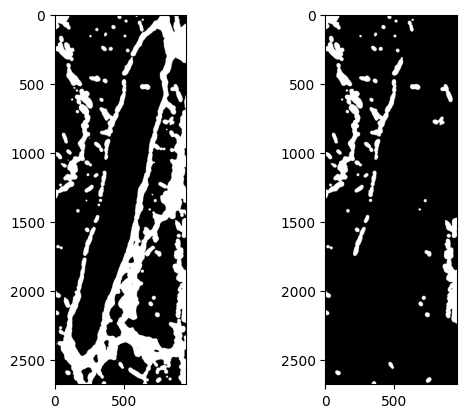

In [79]:
label_img = label(thresholded2)

# 3. Create output image
output = np.zeros_like(thresholded2)
data = regionprops_table(label_img, thresholded2, properties=("label", "area", "eccentricity"))  
#condition = (data['area'] > 50) & (data['area'] < 50000) & (data['eccentricity'] > 0.1)# filter out any nuclei are more than 15um radius equivalent
condition = (data['area'] > 200) & (data['area'] < 50000) & (data['eccentricity'] > 0.2)# filter out any nuclei are more than 15um radius equivalent

input_labels = data['label']
output_labels = input_labels * condition

actual_labelling = util.map_array(label_img, input_labels, output_labels) # only keep the cells with nuclei that pass the volume test
fig, ax = plt.subplots(ncols = 2)
ax[0].imshow((label_img>=1), cmap="gray")

ax[1].imshow((actual_labelling>=1), cmap="gray")


In [80]:
# 4. Process each labeled region
for region in regionprops(label_img):
    if (region.area>200) & (region.area <50000) & (region.eccentricity>0.2):
        region_mask = label_img == region.label
        angle_deg = -np.rad2deg(region.orientation)
        
        selem = np.zeros((125, 125), dtype=bool)
        selem[51:53, :] = 1  # center row = horizontal line
        rotated_selem = rotate(selem.astype(float), angle=90-angle_deg, reshape=False, order=0) > 0.5
        dilated = binary_dilation(region_mask, structure=rotated_selem)

        # Add to output
        output[dilated] = 1



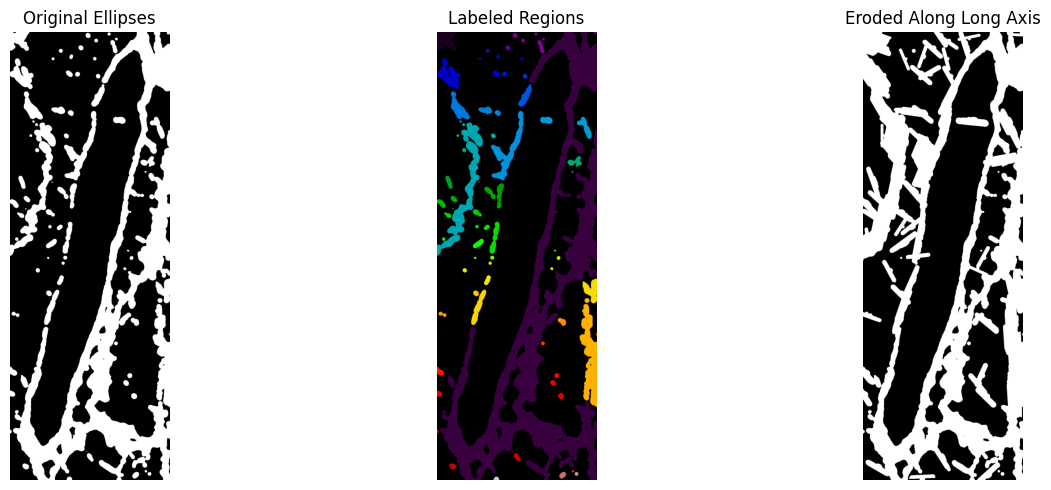

In [81]:

# 5. Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(thresholded2, cmap='gray')
axes[0].set_title("Original Ellipses")
axes[0].axis('off')

axes[1].imshow(label_img, cmap='nipy_spectral')
axes[1].set_title("Labeled Regions")
axes[1].axis('off')

axes[2].imshow(np.logical_or(thresholded2, output), cmap='gray')
axes[2].set_title("Eroded Along Long Axis")
axes[2].axis('off')

plt.tight_layout()
plt.show()

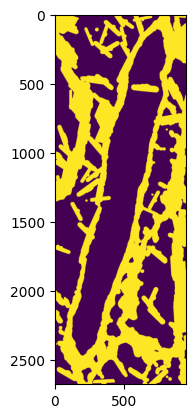

In [82]:
lines = np.logical_or(thresholded2, output)
smoothed = gaussian(lines, sigma=1)
thresh = threshold_triangle(smoothed)
binary = smoothed>thresh
plt.imshow(binary)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import ellipse
from skimage.measure import label, regionprops
from scipy.ndimage import binary_erosion, rotate

import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import ellipse
from skimage.measure import label, regionprops
from scipy.ndimage import binary_dilation, rotate

# 1. Create image with multiple slanted ellipses
image = np.zeros((300, 300), dtype=bool)
ellipses = [
    (80, 80, 40, 20, 30),
    (200, 100, 30, 15, 75),
    (150, 220, 50, 25, -45),
]

for y, x, ay, ax, angle in ellipses:
    rr, cc = ellipse(y, x, ay, ax, rotation=np.deg2rad(angle), shape=image.shape)
    image[rr, cc] = 1

# 2. Label individual ellipses
label_img = label(image)
data = regionprops_table(label_img,properties=("label", "area", "orientation"))
df = pd.DataFrame(data)



1 -30.217811999039565
2 45.0
3 -74.79157371190027


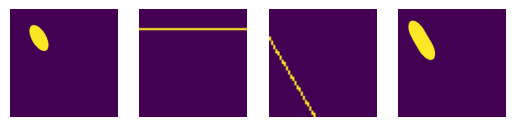

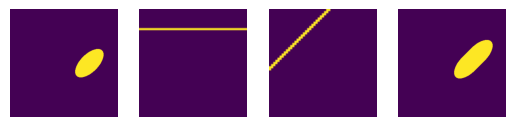

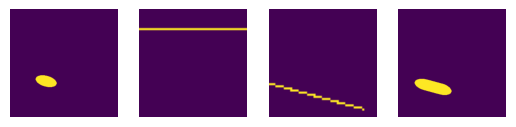

In [19]:

# 3. Prepare output
output = np.zeros_like(image)
# 4. Apply dilation with rotated kernel to each ellipse
for i in np.unique(label_img):
    if i != 0:
        mask = label_img == i
        region = regionprops(mask.astype(int))[0]  # list of 1 element
        orientation_degrees = -np.rad2deg(region.orientation)  # negate to match image coords
        selem = np.zeros((51, 51), dtype=bool)
        selem[9, :] = 1  # center row = horizontal line
        rotated_selem = rotate(selem.astype(float), angle=90-orientation_degrees, reshape=False, order=0) > 0.5
        dilated = binary_dilation(mask, structure=rotated_selem)

        # Add to output
        output[dilated] = 1
        print(i, orientation_degrees)

        fig, ax = plt.subplots(ncols = 4)
        ax[0].imshow(mask)
        ax[1].imshow(selem)
        ax[2].imshow(rotated_selem)
        ax[3].imshow(dilated)
        for a in ax:
            a.set_aspect('equal')
            a.axis("off")


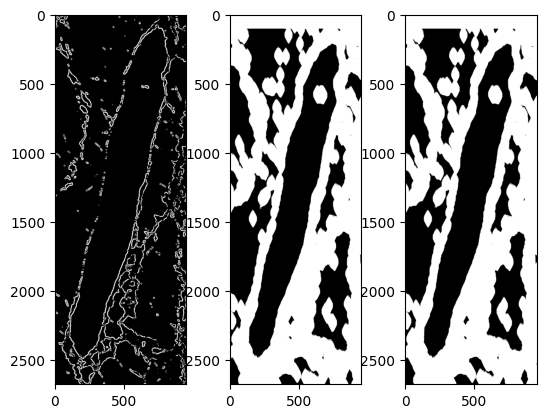

In [39]:
fig, ax = plt.subplots(ncols = 3)
ax[0].imshow(binary_outline, cmap="gray")
ax[1].imshow(filled_outline, cmap="gray")
ax[2].imshow(clean_object, cmap="gray")

ORIG identified area is 12940.0 whole area is 127559.05 ratio is 0.10144321394679562
HERE
RERUN identified area is 31124.0 whole area is 127559.05 ratio is 0.24399679991345186
Red pixels: 5923, Green pixels: 4884, Red:Green ratio: 1.21
Mean radial alignment score: 0.503
Mean radial alignment score: 0.466


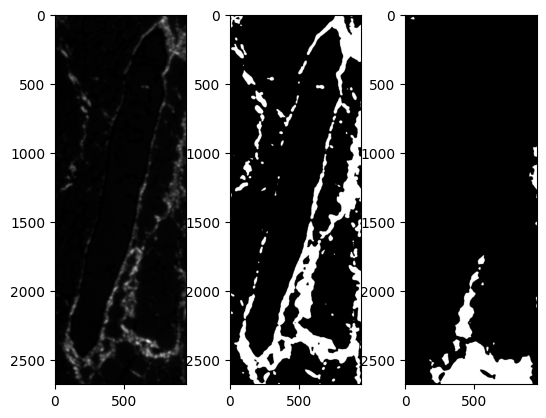

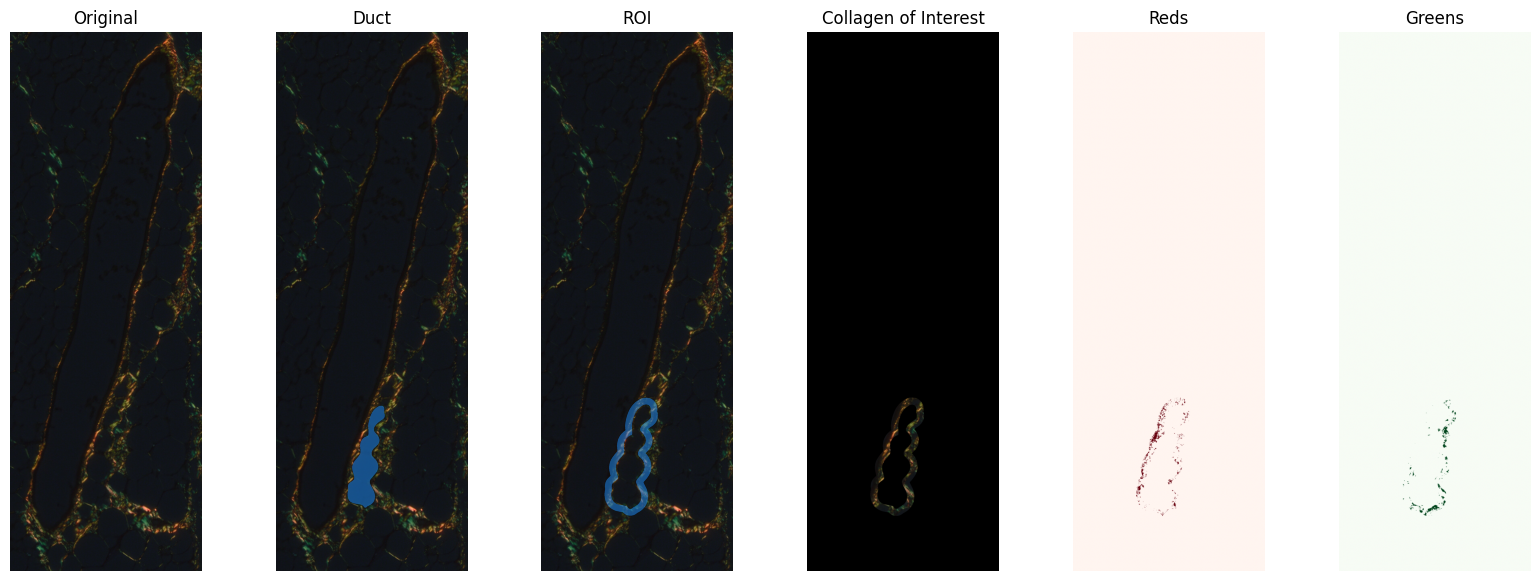

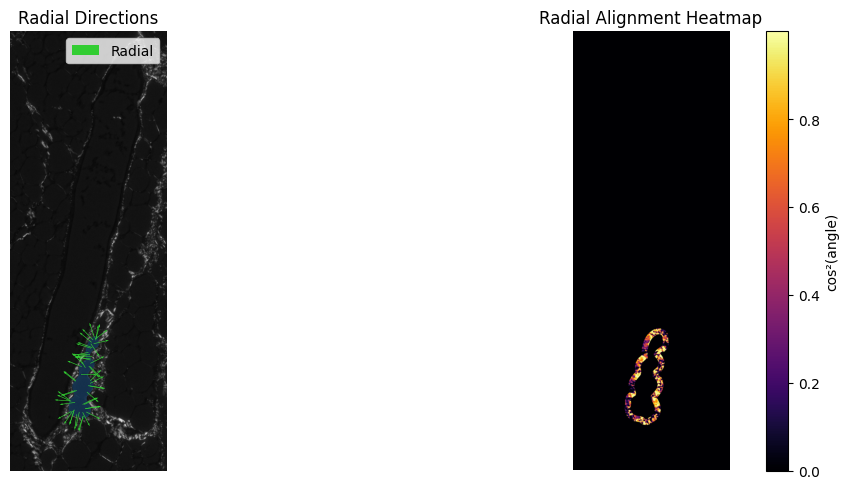

,Image,Total_Collagen,Duct_Area_um2,Ring_Area_um2,Red_Pixels,Green_Pixels,Red_Green_Ratio,Total_Alignment,Thick_Alignment,flag,condition
0,354189_wt_gland1_4,5449035,2331.978648,3739.653121,5923,4884,1.212735,0.5,0.47,none,wt


In [56]:
i=4
outputs = segment_and_quantify(image_paths, i)
outputs


In [11]:
image_root = "C:/Users/itayl/The University of Manchester Dropbox/Isobel Taylor-Hearn/Picrosirius_Red_Stain_Quantification/NicTom_Dataset/Nic"
image_paths = list(pathlib.Path(image_root).rglob("*.{}".format("tif")))
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    outputs = Parallel(n_jobs=3)(delayed(segment_and_quantify)(image_paths, i) for i in range(len(image_paths)))
total = pd.concat(outputs).reset_index()
total.to_csv("NIC_images.csv")


Image Analysis: 100%|██████████| 54/54 [17:48<00:00, 19.79s/it] 


In [12]:
image_root = "C:/Users/itayl/The University of Manchester Dropbox/Isobel Taylor-Hearn/Picrosirius_Red_Stain_Quantification/NicTom_Dataset/Tom"
image_paths = list(pathlib.Path(image_root).rglob("*.{}".format("tif")))
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    outputs = Parallel(n_jobs=3)(delayed(segment_and_quantify)(image_paths, i) for i in range(len(image_paths)))
total = pd.concat(outputs).reset_index()
total.to_csv("TOM_images.csv")


Image Analysis: 100%|██████████| 41/41 [25:14<00:00, 36.93s/it] 


In [13]:
image_root = "C:/Users/itayl/The University of Manchester Dropbox/Isobel Taylor-Hearn/Picrosirius_Red_Stain_Quantification/NicTom_Dataset/NicTom"
image_paths = list(pathlib.Path(image_root).rglob("*.{}".format("tif")))
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    outputs = Parallel(n_jobs=3)(delayed(segment_and_quantify)(image_paths, i) for i in range(len(image_paths)))
total = pd.concat(outputs).reset_index()
total.to_csv("NICTOM_images.csv")

Image Analysis: 100%|██████████| 39/39 [03:04<00:00,  4.74s/it]


In [14]:
image_root = "C:/Users/itayl/The University of Manchester Dropbox/Isobel Taylor-Hearn/Picrosirius_Red_Stain_Quantification/NicTom_Dataset/WT"
image_paths = list(pathlib.Path(image_root).rglob("*.{}".format("tif")))
with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
    outputs = Parallel(n_jobs=3)(delayed(segment_and_quantify)(image_paths, i) for i in range(len(image_paths)))
total = pd.concat(outputs).reset_index()
total.to_csv("WT_images.csv")

Image Analysis: 100%|██████████| 57/57 [19:46<00:00, 20.81s/it] 


In [15]:
nic = pd.read_csv("NIC_images.csv")
tom = pd.read_csv("TOM_images.csv")
nictom = pd.read_csv("NICTOM_images.csv")
wt = pd.read_csv("WT_images.csv")

In [17]:
total_data = pd.concat((nic, tom))
total_data = pd.concat((total_data, nictom))
total_data = pd.concat((total_data, wt))

In [19]:
total_data.columns

Index(['Unnamed: 0', 'index', 'Image', 'Total_Collagen', 'Duct_Area_um2',
       'Ring_Area_um2', 'Red_Pixels', 'Green_Pixels', 'Red_Green_Ratio',
       'Total_Alignment', 'Thick_Alignment', 'flag', 'condition', 'Flag'],
      dtype='object')

In [32]:
print(total_data.shape)
print(total_data[total_data["Duct_Area_um2"]>25].shape)

(191, 14)
(178, 14)


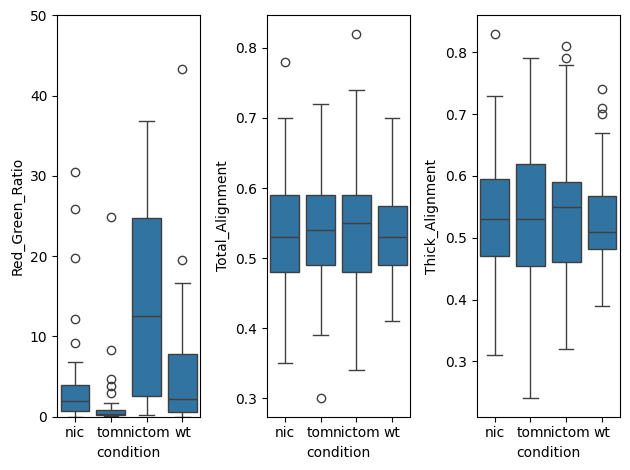

In [38]:
import seaborn as sns

big_ducts = total_data[total_data["Duct_Area_um2"]>25]
fig, ax = plt.subplots(ncols = 3)
sns.boxplot(data = big_ducts.reset_index(), x="condition", y="Red_Green_Ratio", ax=ax[0])
sns.boxplot(data = big_ducts.reset_index(), x="condition", y="Total_Alignment", ax=ax[1])
sns.boxplot(data = big_ducts.reset_index(), x="condition", y="Thick_Alignment", ax=ax[2])
ax[0].set_ylim(0,50)
plt.tight_layout()

(0.0, 50000.0)

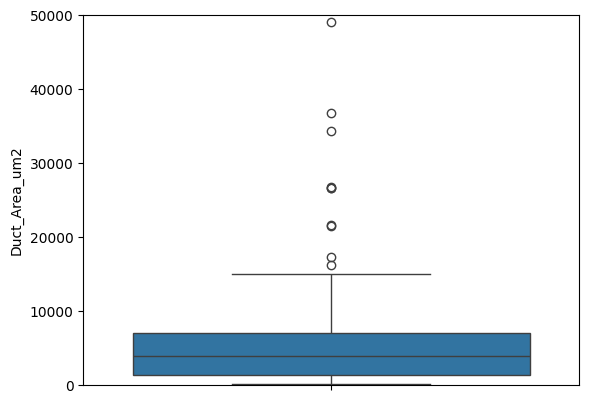

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(data = total_data.reset_index(),  y="Duct_Area_um2", ax=ax)
ax.set_ylim(0,50000)